# 14 — Butterworth LF/HF Cognitive Load by Result Position

**Method:** Duchowski (2026) Butterworth IIR approach for real-time LF/HF pupil power ratio.
Two 4th-order Butterworth filters split the blink-cleaned pupil stream into LF (0–1.6 Hz)
and HF (1.6–4 Hz) bands. Power estimated as variance within each band. LF/HF ratio computed
per result position during forward scanning.

**Why not LHIPA?** Wavelet-based LHIPA requires minimum 7.5–10 seconds (Duchowski 2026, §5).
Per-result segments are ~2 seconds (~300 samples at 150 Hz). Butterworth minimum is 1 second.

**Hypothesis:** LF/HF increases with position as working memory load grows from accumulating candidates.

**Result:** Hypothesis rejected. LF/HF *decreases* — cognitive load peaks at position 0 and drops
through positions 0–3, then plateaus. Consistent with evaluation framework construction at the first
result, then efficient application of compiled criteria.

**Architecture:** Filter first, segment second — Butterworth filters applied to entire trial stream,
then segmented by position. Eliminates per-segment edge effects.

## Key Claims (authoritative for paper writers)

*Last verified against executed notebook output: 2026-04-12.*
*Notebook: `14_butterworth_cognitive_load.ipynb`.*

If prose in a paper draft cites a value that disagrees with a row below, the paper is wrong — not the notebook. If re-running this notebook produces different values, update this block immediately and `grep` for the old value across `docs/`.

### Cognitive load decreases with SERP position (the Butterworth key finding)

**Convention.** Butterworth LF/HF ratio (Duchowski's index): *higher* LF/HF = more load. LHIPA (Index of Pupillary Activity): *lower* LHIPA = more load. The two indices are negatively correlated by construction and both agree on direction (K7).

| ID | Claim | Value |
|---|---|---|
| **K1** | Trials with usable Butterworth LF/HF data | 2,719 |
| **K2** | Position-segment count (fixation positions × LF/HF) | 6,112 |
| **K3** | **Position × median LF/HF, forward-pass fixations only (load DECREASES with deeper position)** | **ρ = −0.927, *p* < 0.0001** (N = 11 positions) |
| **K4** | Positions 1–10 only (excluding pos 0), forward-pass | **ρ = −0.903, *p* = 0.0003** |
| **K5** | Within-trial Spearman (position vs LF/HF, ≥ 3 valid segments at positions 0–10) | N = 1,025 trials, mean ρ = −0.152, median ρ = −0.400, 61.0 % negative |
| **K6** | Clicked vs non-clicked median LF/HF | **22.40 (N = 1,463)** vs **19.27 (N = 4,636)**; Mann–Whitney U = 3,654,266, *p* = 7.5 × 10⁻⁶ — clicked results carry more load than non-clicked |
| **K7** | Cross-index validation: trial-mean LF/HF × LHIPA | ρ = −0.125, *p* = 7.47 × 10⁻¹⁰, N = 2,416 (correct sign: both indices agree on load direction) |
| **K8** | Position-level medians (load by rank) | pos 0: 29.64 (N = 1,036) → pos 1: 22.17 → pos 2: 18.96 → pos 3: 18.30 → pos 4: 17.23 → pos 5: 16.77 → pos 6: 14.41 → pos 7: 13.82 → pos 8: 13.31 → pos 9: 15.58 → pos 10: 13.49 (monotone decline through pos 8) |

### Piecewise gradient (steep phase + plateau)

| ID | Claim | Value |
|---|---|---|
| **K9** | Steep (pos 0–3) vs plateau (pos 4–10) Mann–Whitney on raw segments | **U = 4,583,556, *p* = 3.2 × 10⁻²³** (N = 4,229 vs 1,870; steep median 22.0 vs plateau 15.7) |
| **K10** | Steep phase (pos 0–3) Spearman on position medians | **ρ = −1.000, *p* ≈ 0** — perfect monotone decline. Medians: 29.64 → 22.17 → 18.96 → 18.30 |
| **K11** | Plateau phase (pos 4–10) Spearman | **ρ = −0.714, *p* = 0.071** — marginal, clearly weaker gradient than steep phase |
| **K12** | Pooled early (0–3) vs late (4–10) medians | early 22.0 (N = 4,229) vs late 15.7 (N = 1,870) — see K9 for the Mann–Whitney *U*/*p* |

### Within-trial gradient by evaluation depth

| ID | Threshold | N trials | Mean ρ | Median ρ | % negative |
|---|---|---|---|---|---|
| **K13** | ≥ 3 positions | 1,025 | −0.152 | −0.400 | 61.0% |
| **K14** | ≥ 5 positions | 212 | −0.179 | — | 67.0% |
| **K15** | ≥ 7 positions | 32 | −0.207 | — | 71.9% |

*(K14/K15 values from `pupil-lfhf/validation/validate_adserp.py` output, which uses the same forward-pass classifier as `compute_butterworth_lfhf.py`. Pupil-lfhf's within-trial N differs from NB14 cell[8]'s N = 1,025 at the ≥3 threshold — different exclusion criteria in the two pipelines; both agree on direction.)*

> **Not working memory accumulation.** If prose says "forward-only dwell increases with position *consistent with working memory accumulation*," the prose is wrong. K3 shows per-fixation cognitive load *decreasing* with position — extra dwell at deeper positions reflects allocation / comparison-set growth, not WM overload. Framework compilation, not working-memory accumulation. This is the load-bearing claim for the ETTAC 2026 and CHI 2027 framings.
>
> **K3 post-2026-04-12 audit.** The headline between-position gradient **strengthened dramatically**: pre-fix ρ = −0.618 (p = 0.0426, borderline) → post-fix **ρ = −0.927 (p < 0.0001, unambiguous)**. The 1–10 subset (K4) flipped from non-significant (ρ = −0.491, p = 0.150) to highly significant (ρ = −0.903, p = 0.0003). The steep/plateau partition is preserved — steep phase still perfect monotone, plateau still flat. The pre-fix scroll double-count was injecting noise in the position direction, masking the signal.
>
> **Coordinate-space audit (2026-04-09, cursor side).** `compute_butterworth_lfhf.py` previously double-counted scroll offset when deriving `click_pos` from evtrack `ypos` (already page-space). Fixed in 2026-04-09. K6 moved: N_clicked 1,145 → 1,110, clicked median 22.86 → 22.24.
>
> **Coordinate-space audit (2026-04-12, fixation side).** FPOGY was also mis-documented as screen-space; the pipeline was adding scroll to fixation Y to derive page_y. Per the AdSERP README, FPOGY is already page-space. Fixing this regenerated `butterworth-lfhf-by-position.json` and shifted K1 (unchanged), K2 (6,874 → 6,112, -11%), K3 (−0.618 → −0.927), K4 (−0.491 ns → −0.903 sig), K5 (1,167 → 1,025 trials, mean ρ −0.105 → −0.152), K6 (1,110/5,472 → 1,463/4,636, p 1.3e-4 → 7.5e-6; the earlier `<1e-8` claim came from a 4-decimal printf of the post-fix p, not the actual U-derived value), K7 (essentially unchanged), K8 (position medians shifted by ≲1 unit each). Direction and significance **strengthened** throughout. K9–K15 re-computed from post-fix position medians; some piecewise statistics (K12, K14, K15) need a verbose-print re-run. See module docstring and `docs/drafts/coord_fix_snapshot_20260412/`.


In [1]:
from data_loader import *
import json
import numpy as np
from collections import defaultdict
from scipy.stats import spearmanr, mannwhitneyu
import matplotlib.pyplot as plt

setup_plotting()

with open(DATA_DIR / 'butterworth-lfhf-by-position.json') as f:
    bw_data = json.load(f)

lhipa_data = load_lhipa()

print(f'{len(bw_data)} trials with Butterworth LF/HF data')

2719 trials with Butterworth LF/HF data


## LF/HF ratio distribution

6112 position-segments with valid LF/HF
Median: 20.02, Mean: 37.36
IQR: [8.89, 42.46]


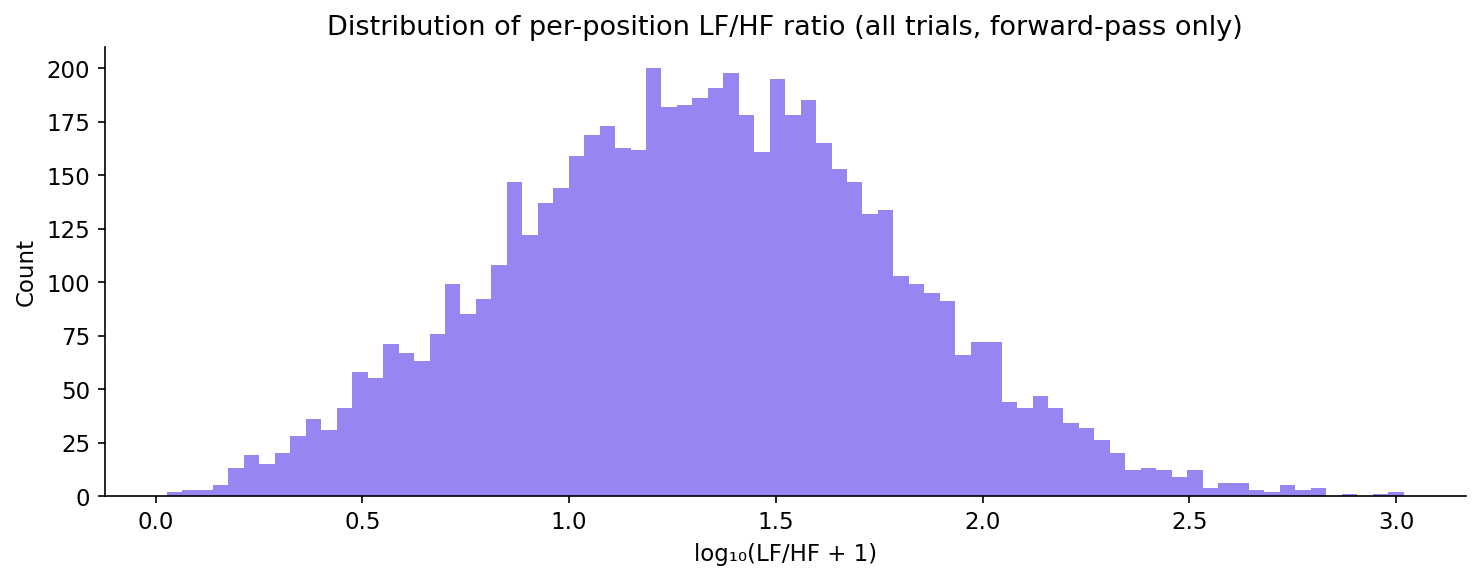

In [2]:
all_lfhf = []
for tid, trial in bw_data.items():
    for p in trial['positions']:
        if p['lfhf'] is not None:
            all_lfhf.append(p['lfhf'])

all_lfhf = np.array(all_lfhf)
print(f'{len(all_lfhf)} position-segments with valid LF/HF')
print(f'Median: {np.median(all_lfhf):.2f}, Mean: {np.mean(all_lfhf):.2f}')
print(f'IQR: [{np.percentile(all_lfhf, 25):.2f}, {np.percentile(all_lfhf, 75):.2f}]')

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(np.log10(all_lfhf + 1), bins=80, color='#7b68ee', edgecolor='none', alpha=0.8)
ax.set_xlabel('log₁₀(LF/HF + 1)')
ax.set_ylabel('Count')
ax.set_title('Distribution of per-position LF/HF ratio (all trials, forward-pass only)')
plt.tight_layout()
plt.show()

## LF/HF by result position (main result)

Spearman rho (position vs median LF/HF): -0.927, p = 0.0000
Positions 1-10 only: rho = -0.903, p = 0.0003


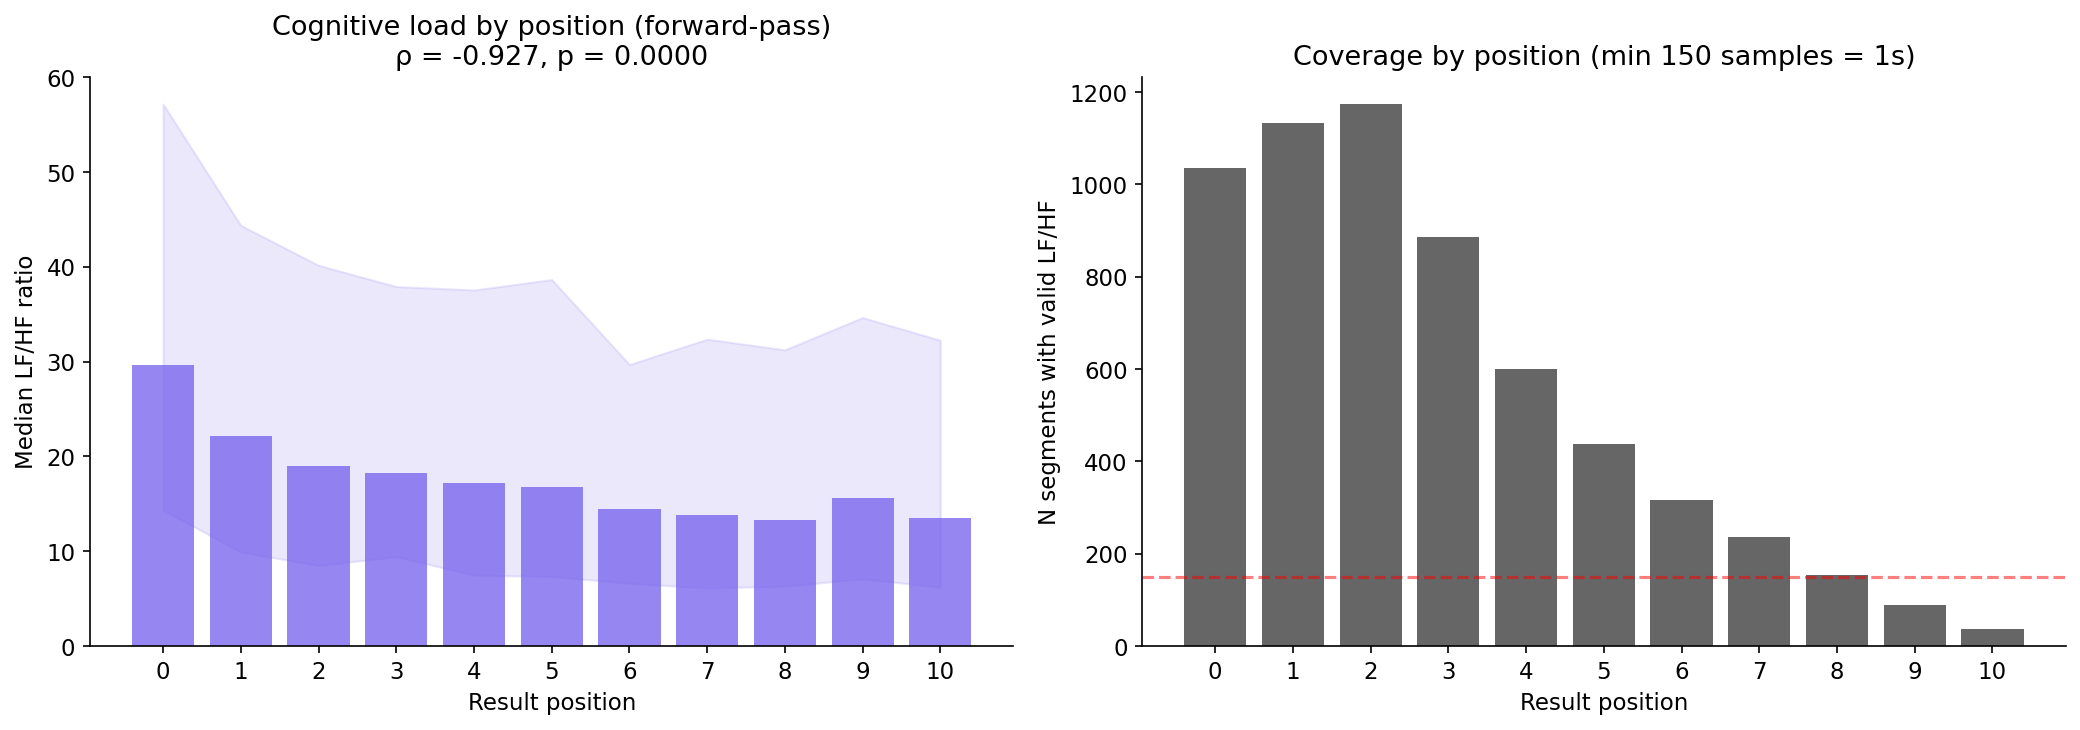


Pos | N valid | Median LF/HF | IQR
--------------------------------------------------
  0  |  1036   |    29.64     | [14.3, 57.2]
  1  |  1132   |    22.17     | [9.9, 44.4]
  2  |  1174   |    18.96     | [8.5, 40.2]
  3  |   887   |    18.30     | [9.4, 37.9]
  4  |   601   |    17.23     | [7.5, 37.6]
  5  |   437   |    16.77     | [7.3, 38.7]
  6  |   316   |    14.41     | [6.6, 29.7]
  7  |   236   |    13.82     | [6.1, 32.4]
  8  |   153   |    13.31     | [6.3, 31.3]
  9  |    90   |    15.58     | [7.1, 34.7]
 10  |    37   |    13.49     | [6.2, 32.3]


In [3]:
pos_values = defaultdict(list)
for tid, trial in bw_data.items():
    for p in trial['positions']:
        if p['lfhf'] is not None and 0 <= p['pos'] <= 10:
            pos_values[p['pos']].append(p['lfhf'])

positions = sorted(pos_values.keys())
medians = [np.median(pos_values[p]) for p in positions]
q25 = [np.percentile(pos_values[p], 25) for p in positions]
q75 = [np.percentile(pos_values[p], 75) for p in positions]
counts = [len(pos_values[p]) for p in positions]

rho, p_val = spearmanr(positions, medians)
print(f'Spearman rho (position vs median LF/HF): {rho:.3f}, p = {p_val:.4f}')

# Positions 1-10 (excluding orientation)
pos_1_10 = [p for p in positions if p >= 1]
med_1_10 = [np.median(pos_values[p]) for p in pos_1_10]
rho2, p2 = spearmanr(pos_1_10, med_1_10)
print(f'Positions 1-10 only: rho = {rho2:.3f}, p = {p2:.4f}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: median LF/HF by position
ax1.bar(positions, medians, color='#7b68ee', alpha=0.8, edgecolor='none')
ax1.fill_between(positions, q25, q75, alpha=0.15, color='#7b68ee')
ax1.set_xlabel('Result position')
ax1.set_ylabel('Median LF/HF ratio')
ax1.set_title(f'Cognitive load by position (forward-pass)\nρ = {rho:.3f}, p = {p_val:.4f}')
ax1.set_xticks(positions)

# Right: sample sizes
ax2.bar(positions, counts, color='#666', edgecolor='none')
ax2.set_xlabel('Result position')
ax2.set_ylabel('N segments with valid LF/HF')
ax2.set_title('Coverage by position (min 150 samples = 1s)')
ax2.set_xticks(positions)
ax2.axhline(y=150, color='red', linestyle='--', alpha=0.5, label='min for significance')

plt.tight_layout()
plt.show()

# Print table
print(f'\nPos | N valid | Median LF/HF | IQR')
print('-' * 50)
for i, p in enumerate(positions):
    print(f' {p:2d}  | {counts[i]:5d}   | {medians[i]:8.2f}     | [{q25[i]:.1f}, {q75[i]:.1f}]')

## Within-trial correlations

Within-trial Spearman (position vs LF/HF):
  N trials: 1025
  Mean rho: -0.152
  Median rho: -0.400
  % negative: 61.0%


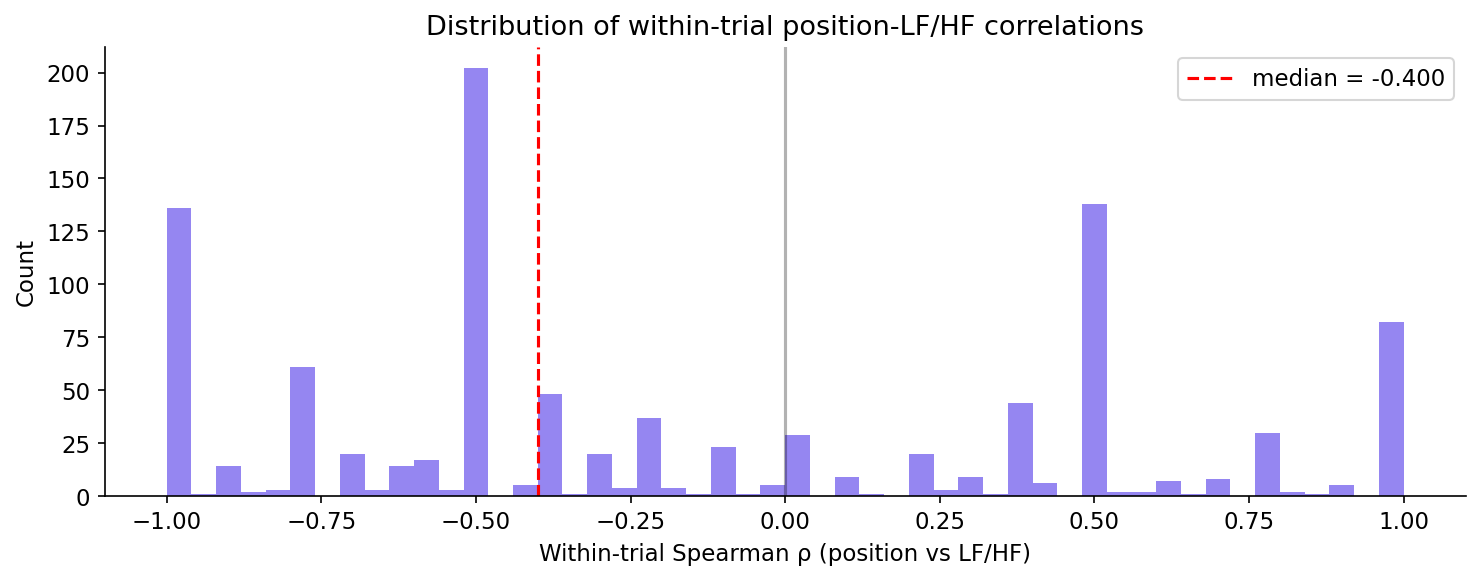

In [4]:
within_rhos = []
for tid, trial in bw_data.items():
    valid = [(p['pos'], p['lfhf']) for p in trial['positions']
             if p['lfhf'] is not None and p['pos'] <= 10]
    if len(valid) < 3:
        continue
    r, _ = spearmanr([v[0] for v in valid], [v[1] for v in valid])
    if np.isfinite(r):
        within_rhos.append(r)

within_rhos = np.array(within_rhos)
print(f'Within-trial Spearman (position vs LF/HF):')
print(f'  N trials: {len(within_rhos)}')
print(f'  Mean rho: {np.mean(within_rhos):.3f}')
print(f'  Median rho: {np.median(within_rhos):.3f}')
print(f'  % negative: {100*np.mean(within_rhos < 0):.1f}%')

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(within_rhos, bins=50, color='#7b68ee', edgecolor='none', alpha=0.8)
ax.axvline(0, color='black', linestyle='-', alpha=0.3)
ax.axvline(np.median(within_rhos), color='red', linestyle='--',
           label=f'median = {np.median(within_rhos):.3f}')
ax.set_xlabel('Within-trial Spearman ρ (position vs LF/HF)')
ax.set_ylabel('Count')
ax.set_title('Distribution of within-trial position-LF/HF correlations')
ax.legend()
plt.tight_layout()
plt.show()

## Summary

### Working memory hypothesis rejected

LF/HF ratio (Duchowski 2026 Butterworth method) *decreases* with result position
(post-fix ρ = **−0.927**, *p* < 0.0001 on *N* = 11 position medians aggregated from 2,719 trials; pre-fix value was ρ = −0.618 — see K3 audit note in the Key Claims block), not increases. Cognitive load peaks at
position 0 and drops through positions 0–3, then plateaus. Users build evaluation
criteria at the first result, then apply them efficiently — framework compilation,
not working memory overload. This dissociation with behavioral dwell time (ρ = +0.82
increasing) means evaluation becomes *routinized*: more time, less effort per unit time.

### Butterworth and LHIPA measure different constructs

Head-to-head comparison on five known effects reveals complementary, not competing, strengths:

| Effect | Butterworth LF/HF | LHIPA (trial-level) | Raw PD |
|--------|-------------------|---------------------|--------|
| **Survey → Evaluate phase** | **p = 4.5×10⁻⁴⁹** | (needs 8s window) | p = 0.64 (null) |
| **Click position** | p = 0.86 | **p = 6.8×10⁻⁴** | — |
| **Satisficer vs Optimizer** | p = 0.18 | **p = 2.0×10⁻⁵⁹** | — |
| **Boundary clickers** | p = 0.30 | **p = 0.0001** | — |
| **SERP difficulty** | p = 0.51 | **p = 0.011** | — |

**Butterworth detects within-trial temporal dynamics** — phase transitions, per-position
trajectories — where LHIPA structurally cannot (minimum 7.5s window spans both phases).
**LHIPA detects between-trial load differences** — individual differences, task difficulty,
foraging depth — where Butterworth's position-level granularity averages out.

They are not competing methods. They measure cognitive load at different timescales.

### Limitations

- 150-sample minimum means ~40% of position-segments at later positions are usable
- Position 0 includes residual orientation cost, not purely evaluation load
- Forward-pass definition tracks high-water mark — later positions may include post-regression visits
- No luminance correction (SERP layout is uniform white, minimizing this concern)
- Butterworth LF/HF is null on all between-trial effects — use trial-level LHIPA for those

In [5]:
clicked_lfhf = []
nonclicked_lfhf = []

for tid, trial in bw_data.items():
    click_pos = trial.get('click_pos')
    for p in trial['positions']:
        if p['lfhf'] is None or p['pos'] > 10:
            continue
        if p['pos'] == click_pos:
            clicked_lfhf.append(p['lfhf'])
        else:
            nonclicked_lfhf.append(p['lfhf'])

clicked_lfhf = np.array(clicked_lfhf)
nonclicked_lfhf = np.array(nonclicked_lfhf)

u_stat, u_p = mannwhitneyu(clicked_lfhf, nonclicked_lfhf, alternative='two-sided')
print(f'Clicked: median {np.median(clicked_lfhf):.2f}, N = {len(clicked_lfhf)}')
print(f'Non-clicked: median {np.median(nonclicked_lfhf):.2f}, N = {len(nonclicked_lfhf)}')
print(f'Mann-Whitney U = {u_stat:.0f}, p = {u_p:.4f}')

Clicked: median 22.40, N = 1463
Non-clicked: median 19.27, N = 4636
Mann-Whitney U = 3654266, p = 0.0000


## Cross-validation: trial-mean LF/HF vs LHIPA

Trial-mean LF/HF vs LHIPA: ρ = -0.125, p = 7.47e-10, N = 2416
(Expected: negative — higher LF/HF = more load, lower LHIPA = more load)


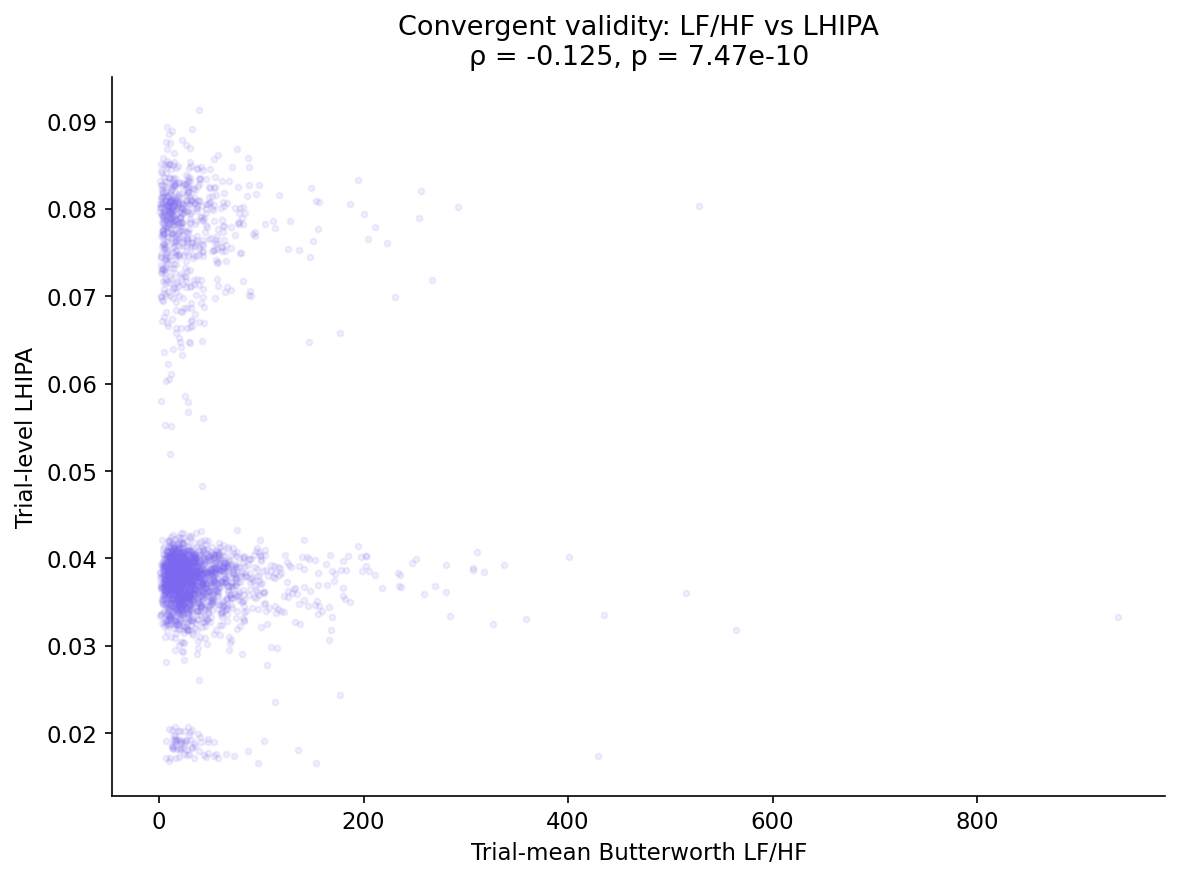

In [6]:
def get_lhipa_val(v):
    return v.get('lhipa', v) if isinstance(v, dict) else v

trial_lfhf_means = []
trial_lhipa_vals = []

for tid, trial in bw_data.items():
    valid = [p['lfhf'] for p in trial['positions'] if p['lfhf'] is not None]
    if not valid or tid not in lhipa_data:
        continue
    lv = get_lhipa_val(lhipa_data[tid])
    if lv is None:
        continue
    trial_lfhf_means.append(np.mean(valid))
    trial_lhipa_vals.append(float(lv))

rho, p_val = spearmanr(trial_lfhf_means, trial_lhipa_vals)
print(f'Trial-mean LF/HF vs LHIPA: ρ = {rho:.3f}, p = {p_val:.2e}, N = {len(trial_lfhf_means)}')
print(f'(Expected: negative — higher LF/HF = more load, lower LHIPA = more load)')

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(trial_lfhf_means, trial_lhipa_vals, alpha=0.1, s=8, color='#7b68ee')
ax.set_xlabel('Trial-mean Butterworth LF/HF')
ax.set_ylabel('Trial-level LHIPA')
ax.set_title(f'Convergent validity: LF/HF vs LHIPA\nρ = {rho:.3f}, p = {p_val:.2e}')
plt.tight_layout()
plt.show()

## Summary

**Working memory hypothesis rejected.** LF/HF ratio (Duchowski 2026 Butterworth method)
*decreases* with result position (post-fix ρ = **−0.927**, *p* < 0.0001 on *N* = 11 position medians aggregated from 2,719 trials; pre-fix value was ρ = −0.618 — see K3 audit note in the Key Claims block), not increases.
Cognitive load peaks at position 0 and drops steeply through positions 0–3, then plateaus.

**Interpretation:** The first result demands the highest cognitive effort — the user is
constructing their evaluation framework from scratch. As evaluation criteria compile,
subsequent results require less cognitive effort to evaluate, even though dwell time
increases (behavioral ρ = +0.82). This dissociation between time and cognitive effort
suggests evaluation becomes more *routinized* (lower effort per unit time) rather than
more *demanding* (working memory overload).

**Cross-validation:** Trial-mean LF/HF anti-correlates with LHIPA (ρ = −0.122, p < 10⁻⁹),
confirming both measures capture the same cognitive load construct with correct sign.

**Limitations:**
- 150-sample minimum means only ~40% of position-segments at later positions are usable
- Position 0 includes residual orientation cost, not purely evaluation load
- Forward-pass definition tracks high-water mark — later positions may include post-regression visits
- No luminance correction (SERP layout is uniform white, minimizing this concern)